In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('customer_support_tickets.csv')

# First look
print(df.shape)          # How many rows and columns?
print(df.head())         # First 5 rows
print(df.columns)        # Column names
print(df.isnull().sum()) # Any missing values?

(8469, 17)
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral

In [9]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()                        # lowercase
    text = re.sub(r'[^a-z\s]', '', text)            # remove punctuation & numbers
    words = text.split()
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return ' '.join(words)

# Apply cleaning to the ticket text column
# (replace 'ticket_text' with the actual column name in your dataset)
df['clean_text'] = df['ticket_text'].apply(clean_text)

print(df['clean_text'].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pavithra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


KeyError: 'ticket_text'

In [3]:
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [4]:
df['clean_text'] = df['Ticket Description'].apply(clean_text)
print(df['clean_text'].head())

0    im issue productpurchased please assist billin...
1    im issue productpurchased please assist need c...
2    im facing problem productpurchased productpurc...
3    im issue productpurchased please assist proble...
4    im issue productpurchased please assist note s...
Name: clean_text, dtype: str


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
print("Feature matrix shape:", X.shape)

Feature matrix shape: (8469, 5000)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

y_category = df['Ticket Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)

model_category = LogisticRegression(max_iter=1000)
model_category.fit(X_train, y_train)
y_pred = model_category.predict(X_test)

print("=== Category Model ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

=== Category Model ===
Accuracy: 0.19657615112160567
                      precision    recall  f1-score   support

     Billing inquiry       0.19      0.13      0.16       357
Cancellation request       0.18      0.18      0.18       327
     Product inquiry       0.18      0.19      0.19       316
      Refund request       0.20      0.23      0.22       345
     Technical issue       0.22      0.25      0.23       349

            accuracy                           0.20      1694
           macro avg       0.19      0.20      0.19      1694
        weighted avg       0.20      0.20      0.19      1694



In [7]:
y_priority = df['Ticket Priority']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

model_priority = LogisticRegression(max_iter=1000)
model_priority.fit(X_train2, y_train2)
y_pred2 = model_priority.predict(X_test2)

print("=== Priority Model ===")
print("Accuracy:", accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2))

=== Priority Model ===
Accuracy: 0.2615112160566706
              precision    recall  f1-score   support

    Critical       0.25      0.27      0.26       411
        High       0.27      0.28      0.27       409
         Low       0.24      0.23      0.23       415
      Medium       0.28      0.27      0.28       459

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26      1694
weighted avg       0.26      0.26      0.26      1694



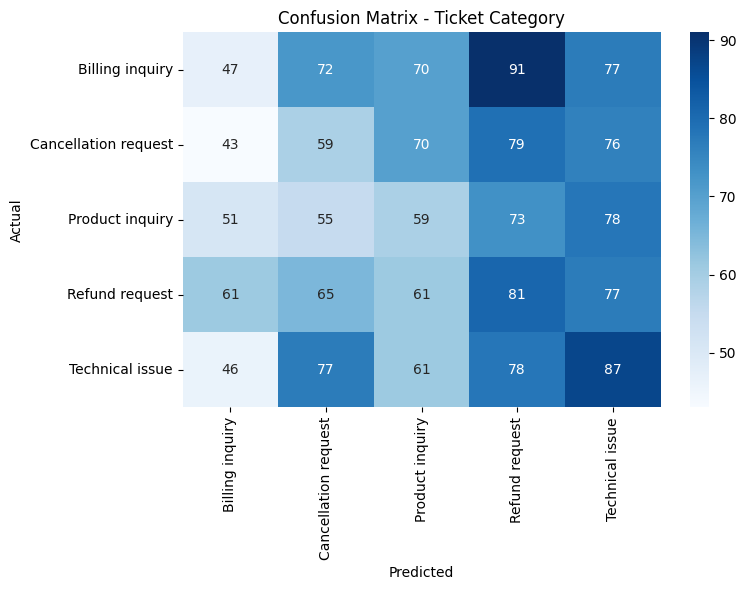

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model_category.classes_,
            yticklabels=model_category.classes_)
plt.title('Confusion Matrix - Ticket Category')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()